# Helper functions and Imports

In [1]:
# ----------------------------------
# Aurora Project: Advanced Autoencoder for Single CDF Data
# ----------------------------------

import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D, Reshape, LSTM, Dense, BatchNormalization,
    Dropout, Attention, GlobalAveragePooling1D, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

# ----------------------------------
# 1. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders (Update these paths as per your directory structure)
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

    Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
        theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
        phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
        energy = fpi_cdf.varget('mms1_des_energy_brst')  # Energy levels
    return epoch, dist_data, theta, phi, energy  # Return energy

def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
    return epoch, bulk_velocity

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """Calculate pitch angle distribution using look direction (phi, theta) and magnetic field."""
    # Convert theta and phi to radians
    theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
    phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

    # Create meshgrid for phi and theta
    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)

    # Compute look direction unit vector components
    look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
    look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
    look_direction_z = np.cos(theta_grid)

    # Stack components to form the look direction vectors
    look_direction = np.stack(
        [look_direction_x, look_direction_y, look_direction_z],
        axis=2
    )  # Shape: (phi_bins, theta_bins, 3)

    # Flatten look_direction for efficient computation
    look_direction_flat = look_direction.reshape(-1, 3)  # Shape: (phi_bins * theta_bins, 3)

    # Initialize the pitch angles array
    time_steps = b_field.shape[0]
    pitch_angles = np.zeros((time_steps, phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

    # Iterate over each time step
    for t in range(time_steps):
        # Normalize magnetic field vector
        b_vector = b_field[t, :3]  # Assuming b_field has shape (time_steps, 3)
        b_magnitude = np.linalg.norm(b_vector)
        if b_magnitude == 0:
            b_unit = np.zeros(3)
        else:
            b_unit = b_vector / b_magnitude

        # Compute dot product between look direction and magnetic field
        v_dot_b = np.dot(look_direction_flat, b_unit)  # Shape: (phi_bins * theta_bins,)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)  # Ensure values are within valid range

        # Calculate pitch angles in degrees
        pitch_angles_flat = np.arccos(v_dot_b) * (180.0 / np.pi)

        # Reshape back to (phi_bins, theta_bins)
        pitch_angles[t] = pitch_angles_flat.reshape(phi_bins.size, theta_bins.size)

    return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)



# Match fgm and fpi file function

In [65]:

# ----------------------------------
# 2. Match and Select the First Matched File Set
# ----------------------------------

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

# Perform file matching
matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)

# Check if any matched files exist
if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

# Select the first matched set for processing
first_match = matched_files[0]
fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename = first_match

print("\nSelected First Matched File Set:")
print(f"  FPI Distribution File: {fpi_dist_filename}")
print(f"  FGM File: {fgm_filename}")
print(f"  FPI Moments File: {fpi_moms_filename}")

# Paths to the matched files
fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
fgm_filepath = os.path.join(fgm_folder, fgm_filename)
fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)



No matching FPI Moments file for timestamp 2024-03-01 23:22:33
No matching FPI Moments file for timestamp 2024-03-01 23:29:13

Selected First Matched File Set:
  FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
  FGM File: mms1_fgm_brst_l2_20240301230743_v5.441.0.cdf
  FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230743_v3.4.0.cdf


In [3]:
# Load FPI Distribution data
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)  # Get energy
print("Loaded FPI Distribution data.")


Loaded FPI Distribution data.


In [4]:
dist_data[0,0,0]

array([8.1388616e-26, 3.1650961e-26, 2.7812287e-26, 3.2546814e-26,
       1.9050412e-26, 2.6141300e-26, 1.3132448e-26, 1.6175932e-26,
       1.1448285e-26, 4.4788079e-27, 1.8488240e-27, 8.6069183e-28,
       2.7895916e-28, 5.5479488e-29, 1.6626767e-29, 9.9890237e-30,
       6.0060043e-30, 0.0000000e+00, 2.1778662e-30, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
      dtype=float32)

# Loading data

In [5]:
# ----------------------------------
# 3. Load and Preprocess Data from the Matched File Set
# ----------------------------------

# Load FGM data
fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
print("\nLoaded FGM data.")

# Load FPI Distribution data
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)  # Get energy
print("Loaded FPI Distribution data.")

# Load FPI Moments data
moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
print("Loaded FPI Moments data.")

# Interpolate magnetic field to match FPI timestamps
b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
print("Interpolated magnetic field data to match FPI timestamps.")

# Prepare phi_bins and theta_bins
# Since phi and theta dimensions remain constant, extract them directly
# Check the shape of phi and theta to ensure they are 1D
if phi.ndim == 1:
    phi_bins = phi.flatten()  # Shape: (phi_bins=32,)
elif phi.ndim == 2:
    # If phi has a time dimension, extract from the first time step
    phi_bins = phi[0].flatten()
    print("Phi has an extra time dimension. Extracted phi from the first time step.")
else:
    raise ValueError("Unexpected shape for phi_bins.")

if theta.ndim == 1:
    theta_bins = theta.flatten()  # Shape: (theta_bins=16,)
elif theta.ndim == 2:
    # If theta has a time dimension, extract from the first time step
    theta_bins = theta[0].flatten()
    print("Theta has an extra time dimension. Extracted theta from the first time step.")
else:
    raise ValueError("Unexpected shape for theta_bins.")

# Verify shapes
print(f"Phi bins shape: {phi_bins.shape}")     # Expected: (32,)
print(f"Theta bins shape: {theta_bins.shape}") # Expected: (16,)

# Compute pitch angles using the provided function
pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
print("Calculated pitch angles.")

# Do not transpose pitch_angles; keep (time_steps, phi_bins, theta_bins)
print(f"pitch_angles shape: {pitch_angles.shape}")  # Should be (4333,32,16)

# Normalize pitch angles to [0, 1] for input to the model
pitch_angles_normalized = pitch_angles / 180.0  # Shape: (4333,32,16)

# Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)

# CHECK THIS I THINK ITS ALREADY ENERGY
# Original shape: (time_steps, energy_levels=32, phi_bins=32, theta_bins=16)
#dist_data_transposed = dist_data.transpose(0, 3, 2, 1)  # Swap axes 1 and 3 to get (4333,32,16,32)
dist_data_transposed = dist_data


print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Should be (4333,32,16,32)

# Ensure that pitch_angles and dist_data_transposed have matching phi_bins and theta_bins
if pitch_angles_normalized.shape[1] != dist_data_transposed.shape[1] or \
   pitch_angles_normalized.shape[2] != dist_data_transposed.shape[2]:
    raise ValueError("Mismatch in phi_bins or theta_bins dimensions between pitch_angles and dist_data_transposed.")

# Expand pitch_angles to add a new feature (energy_levels +1)
pitch_angles_expanded = pitch_angles_normalized[..., np.newaxis]  # Shape: (4333,32,16,1)
print(f"Pitch Angles Expanded Shape: {pitch_angles_expanded.shape}")  # Shape: (4333,32,16,1)

# Concatenate distribution data and pitch angles along the energy_levels axis
X_data = np.concatenate((
    dist_data_transposed,
    pitch_angles_expanded
), axis=3)  # Shape: (4333,32,16,33)
X_data = X_data.astype('float32')
print(f"Input Data Shape with Pitch Angles: {X_data.shape}")  # Should be (4333,32,16,33)





Loaded FGM data.
Loaded FPI Distribution data.
Loaded FPI Moments data.
Interpolated magnetic field data to match FPI timestamps.
Phi has an extra time dimension. Extracted phi from the first time step.
Phi bins shape: (32,)
Theta bins shape: (16,)
Calculated pitch angles.
pitch_angles shape: (4333, 32, 16)
Transposed Distribution Data Shape: (4333, 32, 16, 32)
Pitch Angles Expanded Shape: (4333, 32, 16, 1)
Input Data Shape with Pitch Angles: (4333, 32, 16, 33)


# Data Split

In [6]:
# ----------------------------------
# 4. Split Data into Training, Validation, and Test Sets
# ----------------------------------

# Define split proportions
total_samples = X_data.shape[0]
n_train = int(0.8 * total_samples)     # 50% Training
k_val = int(0.10 * total_samples)      # 25% Validation
k_test = total_samples - n_train - k_val  # Remaining 25% Test

print(f"\nTotal samples: {total_samples}")
print(f"Training samples: {n_train}, Validation samples: {k_val}, Test samples: {k_test}")

# Split the data
X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:]

print(f"Training Data Shape: {X_train.shape}")    # (n_train,32,16,33)
print(f"Validation Data Shape: {X_val.shape}")    # (k_val,32,16,33)
print(f"Test Data Shape: {X_test.shape}")          # (k_test,32,16,33)

# Reshape data to include time_steps=1
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1], X_train.shape[2], X_train.shape[3]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1], X_test.shape[2], X_test.shape[3]))

print(f"Reshaped Training Data Shape: {X_train.shape}")  # (n_train,1,32,16,33)
print(f"Reshaped Validation Data Shape: {X_val.shape}")  # (k_val,1,32,16,33)
print(f"Reshaped Test Data Shape: {X_test.shape}")        # (k_test,1,32,16,33)



Total samples: 4333
Training samples: 3466, Validation samples: 433, Test samples: 434
Training Data Shape: (3466, 32, 16, 33)
Validation Data Shape: (433, 32, 16, 33)
Test Data Shape: (434, 32, 16, 33)
Reshaped Training Data Shape: (3466, 1, 32, 16, 33)
Reshaped Validation Data Shape: (433, 1, 32, 16, 33)
Reshaped Test Data Shape: (434, 1, 32, 16, 33)


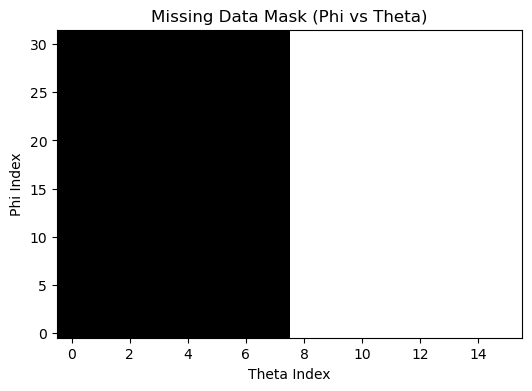

Mask applied to test set.


In [7]:
# ----------------------------------
# 5. Apply Mask to the Test Set Only
# ----------------------------------

# Create a 2D mask for phi_bins x theta_bins
mask_2d = np.zeros((X_data.shape[1], X_data.shape[2]), dtype=bool)
mask_2d[:, X_data.shape[2]//2:] = True  # Masking the right half

# Visualize the mask (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()

# Function to apply mask
def apply_mask(X, mask):
    """
    Apply a 2D mask to the distribution data channels (0-31).

    Parameters:
    - X: Input data array of shape (samples, time_steps, phi_bins, theta_bins, channels)
    - mask: 2D boolean array of shape (phi_bins, theta_bins)

    Returns:
    - X_masked: Masked data array
    """
    # Expand mask dimensions to match X shape
    mask_expanded = mask[np.newaxis, np.newaxis, :, :, np.newaxis]  # (1, 1, phi_bins, theta_bins, 1)
    mask_broadcast = np.tile(mask_expanded, (X.shape[0], X.shape[1], 1, 1, X.shape[4]))  # (samples, time_steps, phi_bins, theta_bins, channels)

    # Set masked regions to 0.0 in the distribution data channels (channels 0-31)
    X_masked = X.copy()
    X_masked[..., :32][mask_broadcast[..., 0]] = 0.0  # Assuming channels 0-31 are energy levels

    return X_masked

# Apply mask to the test set only
X_test_masked = apply_mask(X_test, mask_2d)
print("Mask applied to test set.")


In [8]:
sample_index = 0  # Choose any valid index within X_test_masked

# Inspect masked regions across all energy channels
masked_sample = X_test_masked[sample_index, 0, :, :, :32]  # Shape: (32,16,32)

# Check if the masked regions are set to 0
masked_regions = masked_sample[:, :, 0]  # Inspect the first energy channel
print(f"Masked Regions in First Energy Channel:\n{masked_regions}")

# Similarly, check other energy channels
for energy_idx in range(32):
    masked_regions = masked_sample[:, :, energy_idx]
    if not np.all((masked_regions[:, 8:] == 0)):
        print(f"Energy Channel {energy_idx} not fully masked in expected regions.")


Masked Regions in First Energy Channel:
[[9.78452530e-26 1.77397105e-25 3.39685848e-25 2.01336877e-25
  2.98833207e-25 2.82066979e-25 5.61159558e-25 3.75548229e-25
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.67389073e-25 2.23689743e-25 5.37036351e-26 5.47081139e-26
  1.42099844e-25 2.08964841e-25 1.56398392e-25 1.94813243e-25
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.16487540e-25 7.99396697e-26 2.97044249e-26 1.21626796e-25
  3.46772974e-25 2.90798708e-25 3.43322792e-25 1.97477498e-25
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.06545109e-25 2.65762648e-26 3.28144147e-25 2.00156396e-25
  1.58205796e-25 6.61664911e-26 6.88408837e-26 1.05751390e-25
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000

In [ ]:
y

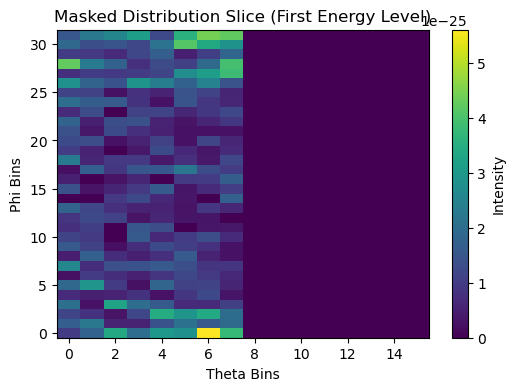

In [9]:
import matplotlib.pyplot as plt

# Visualize a distribution slice after masking for a specific energy channel
plt.figure(figsize=(6, 4))
plt.imshow(X_test_masked[0, :, :, :, 0], aspect='auto', origin='lower', cmap='viridis')  # First energy level
plt.title('Masked Distribution Slice (First Energy Level)')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')
plt.show()


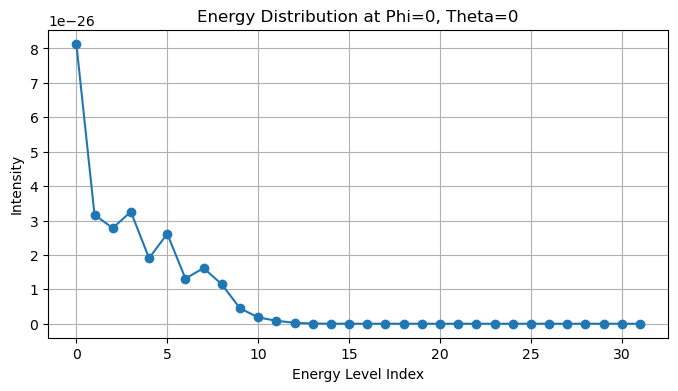

In [10]:
import matplotlib.pyplot as plt

# Plot energy distribution for a specific phi and theta bin
phi_bin = 0  # First phi bin
theta_bin = 0  # First theta bin
energy_levels = np.arange(32)  # Assuming 32 energy levels

plt.figure(figsize=(8, 4))
plt.plot(energy_levels, dist_data_transposed[0, phi_bin, theta_bin, :], marker='o')
plt.title(f'Energy Distribution at Phi={phi_bin}, Theta={theta_bin}')
plt.xlabel('Energy Level Index')
plt.ylabel('Intensity')
plt.grid(True)
plt.show()


# Model 

In [13]:
# ----------------------------------
# 6. Define the New Model Architecture
# ----------------------------------

def build_new_model(phi_bins=32, theta_bins=16, energy_levels=32):
    """
    Build the new model architecture as specified.

    Parameters:
    - phi_bins: Number of phi bins.
    - theta_bins: Number of theta bins.
    - energy_levels: Number of energy levels.

    Returns:
    - model: Compiled Keras model.
    """
    # Define the input shape with variable time steps
    inputs = Input(shape=(None, phi_bins, theta_bins, energy_levels + 1), name='input_layer')  # +1 for pitch_angles

    # General Feature Extraction (Conv3D Block 1)
    x = Conv3D(filters=64, kernel_size=(3, 3, 3), activation='relu', padding="same")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)  # Pool only spatial dimensions

    x = Conv3D(filters=128, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)

    # Intermediate Feature Extraction (Conv3D Block 2)
    x = Conv3D(filters=256, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)

    x = Conv3D(filters=512, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 1), padding="same")(x)  # Avoid aggressive shrinking

    # Reshape Conv3D output for LSTM
    # Use Lambda layer to handle dynamic dimensions
    def reshape_for_lstm(tensor):
        shape = K.shape(tensor)
        batch_size, time_steps, new_phi, new_theta, channels = shape[0], shape[1], shape[2], shape[3], shape[4]
        return K.reshape(tensor, (batch_size, time_steps, new_phi * new_theta * channels))

    x = Lambda(reshape_for_lstm)(x)  # Shape: (batch_size, time_steps, new_phi * new_theta * channels)

    # Temporal Modeling (LSTM Block)
    x = LSTM(units=512, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = LSTM(units=256, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Extra LSTM for Rare Events
    x = LSTM(units=128, return_sequences=True)(x)
    x = BatchNormalization()(x)

    # Attention Mechanism for Rare Events
    attention1 = Attention()([x, x])  # Self-attention
    attention2 = Attention()([attention1, attention1])  # Refine focus

    x = GlobalAveragePooling1D()(attention2)

    # Fully Connected Layers for Reconstruction
    x = Dense(units=phi_bins * theta_bins * energy_levels, activation='relu')(x)
    x = BatchNormalization()(x)
    outputs = Reshape((phi_bins, theta_bins, energy_levels))(x)

    # Model definition
    model = Model(inputs=inputs, outputs=outputs, name='AdvancedConvLSTMAttentionModel')
    return model

# Instantiate the model with corrected phi_bins and theta_bins
model = build_new_model(phi_bins=32, theta_bins=16, energy_levels=32)
model.summary()

# ----------------------------------
# 7. Compile the Model
# ----------------------------------

# Compile the model with Mean Squared Error loss
model.compile(optimizer='adam', loss='mean_squared_error')
print("\nModel compiled with Mean Squared Error loss.")



Model: "AdvancedConvLSTMAttentionModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling3d_4 (MaxPoolin  (None, None, 16, 8, 64)      0         [


Model compiled with Mean Squared Error loss.


In [60]:
# # ----------------------------------
# # 8. Define Custom Loss Functions
# # ----------------------------------

# # Reshape X_train to (time_steps, phi_bins, theta_bins, energy_levels)
# # X_train_reshaped = X_train.reshape(-1, phi_bins, theta_bins, energy_levels)  # Shape: (1000, 16, 32, 32)

# # **Important:** Ensure that the Skymap class expects data in (theta_bins, phi_bins), not (phi_bins, theta_bins)
# # Thus, transpose the data to (time_steps, theta_bins, phi_bins, energy_levels)
# #3466

# """ Example of how to calculate moments from skymaps """
# import cdflib

# from skymaps.skymap import Skymap, plotMomentsTimeSeries

# f = dist_data_transposed[0:n_train]

# # Timestep Azimuth Elevation Energy
# f = f.transpose(0, 3, 2, 1)
# # Timestep Energy Elevation Azimuth

# steps = f.shape[0]
# skymap = Skymap(steps, "MMS1_skymaps", nen=f.shape[1])
# skymap.skymap = f
# moments = skymap.momsTS

# actual_density_test=moments.density

# # Convert actual_density to a tensor for use in the custom loss function
# actual_density_tensor = tf.convert_to_tensor(actual_density, dtype=tf.float32)

# def calculate_density(cube):
#     """
#     Calculate the 'density' moment of the cube by summing over spatial dimensions.

#     Parameters:
#     - cube (Tensor): 5D tensor with shape (batch, phi_bins, theta_bins, energy_levels, channels).

#     Returns:
#     - density: Summed 'density' moment.
#     """
#     return K.sum(cube, axis=(1, 2, 3))  # Sum over phi, theta, and energy dimensions

# def density_loss(y_true, y_pred):
#     """
#     Custom loss function based on the difference in densities between actual and predicted cubes.

#     Parameters:
#     - y_true (Tensor): Actual cube.
#     - y_pred (Tensor): Predicted cube.
#     """
#     predicted_density = calculate_density(y_pred)
#     return K.mean(K.square(actual_density_tensor - predicted_density))  # Mean squared difference of densities

# def combined_loss(y_true, y_pred):
#     """
#     Custom loss that combines MSE and density-based loss.
#     Calculates the mean of MSE and density loss.

#     Parameters:
#     - y_true (Tensor): Actual cube.
#     - y_pred (Tensor): Predicted cube.
#     """
#     # Calculate MSE
#     mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    
#     # Calculate density loss
#     density = density_loss(y_true, y_pred)
    
#     # Combine the two losses
#     return K.mean(mse + density) / 2.0

NameError: name 'actual_density' is not defined

In [14]:
# ----------------------------------
# 8. Train the Model
# ----------------------------------

# Set up early stopping and model checkpointing
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss for stopping
    patience=250,               # Number of epochs with no improvement after which to stop
    restore_best_weights=True  # Restore the best weights after stopping
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Define training parameters
epochs = 500  # Adjust as needed
batch_size = 100 

# Prepare training and validation targets
# Target is the PSD cube (channels 0 to 31)
y_train = X_train[..., :-1]  # All channels except the last one (pitch_angles) => Shape: (n_train,1,32,16,32)
y_val = X_val[..., :-1]      # All channels except the last one (pitch_angles) => Shape: (k_val,1,32,16,32)

# Reshape targets to match output shape
# Model output shape: (batch_size, phi_bins=32, theta_bins=16, energy_levels=32)
y_train = y_train[:, 0, :, :, :]  # Shape: (n_train,32,16,32)
y_val = y_val[:, 0, :, :, :]      # Shape: (k_val,32,16,32)

# Verify shapes
print(f"X_train shape: {X_train.shape}")          # Expected: (2166,1,32,16,33)
print(f"X_val shape: {X_val.shape}")              # Expected: (1083,1,32,16,33)
print(f"y_train shape: {y_train.shape}")          # Expected: (2166,32,16,32)
print(f"y_val shape: {y_val.shape}")              # Expected: (1083,32,16,32) 

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,  # Shuffle the data
    validation_data=(X_val, y_val),  # Validation set is unmasked
    callbacks=[early_stopping, checkpoint]  # Apply early stopping and checkpoint
)

print("\nModel training completed.")



X_train shape: (3466, 1, 32, 16, 33)
X_val shape: (433, 1, 32, 16, 33)
y_train shape: (3466, 32, 16, 32)
y_val shape: (433, 32, 16, 32)
Epoch 1/500
35/35 [==============================] - ETA: 0s - loss: 0.2469
Epoch 1: val_loss improved from inf to 0.00001, saving model to best_model.h5
35/35 [==============================] - 23s 461ms/step - loss: 0.2469 - val_loss: 1.3971e-05
Epoch 2/500
35/35 [==============================] - ETA: 0s - loss: 0.0023
Epoch 2: val_loss improved from 0.00001 to 0.00001, saving model to best_model.h5
35/35 [==============================] - 15s 433ms/step - loss: 0.0023 - val_loss: 1.0381e-05
Epoch 3/500
35/35 [==============================] - ETA: 0s - loss: 5.0575e-04
Epoch 3: val_loss improved from 0.00001 to 0.00001, saving model to best_model.h5
35/35 [==============================] - 15s 425ms/step - loss: 5.0575e-04 - val_loss: 7.4539e-06
Epoch 4/500
35/35 [==============================] - ETA: 0s - loss: 1.0166e-04
Epoch 4: val_loss improv

Epoch 35/500
35/35 [==============================] - ETA: 0s - loss: 7.8624e-05
Epoch 35: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 410ms/step - loss: 7.8624e-05 - val_loss: 7.4766e-05
Epoch 36/500
35/35 [==============================] - ETA: 0s - loss: 5.9383e-05
Epoch 36: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 404ms/step - loss: 5.9383e-05 - val_loss: 5.5023e-05
Epoch 37/500
35/35 [==============================] - ETA: 0s - loss: 6.1380e-05
Epoch 37: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 404ms/step - loss: 6.1380e-05 - val_loss: 3.1026e-04
Epoch 38/500
35/35 [==============================] - ETA: 0s - loss: 7.1429e-05
Epoch 38: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 7.1429e-05 - val_loss: 0.0045
Epoch 39/500
35/35 [==============================] - ETA: 0s - loss: 2.1246e-04
Epoch 39: val_l

Epoch 107/500
35/35 [==============================] - ETA: 0s - loss: 2.8006e-08
Epoch 107: val_loss improved from 0.00000 to 0.00000, saving model to best_model.h5
35/35 [==============================] - 14s 409ms/step - loss: 2.8006e-08 - val_loss: 2.3487e-09
Epoch 108/500
35/35 [==============================] - ETA: 0s - loss: 3.7514e-08
Epoch 108: val_loss improved from 0.00000 to 0.00000, saving model to best_model.h5
35/35 [==============================] - 14s 411ms/step - loss: 3.7514e-08 - val_loss: 1.5684e-09
Epoch 109/500
35/35 [==============================] - ETA: 0s - loss: 9.9584e-08
Epoch 109: val_loss improved from 0.00000 to 0.00000, saving model to best_model.h5
35/35 [==============================] - 14s 408ms/step - loss: 9.9584e-08 - val_loss: 1.0452e-09
Epoch 110/500
35/35 [==============================] - ETA: 0s - loss: 6.2865e-08
Epoch 110: val_loss improved from 0.00000 to 0.00000, saving model to best_model.h5
35/35 [==============================] - 1

35/35 [==============================] - 14s 403ms/step - loss: 4.9193e-07 - val_loss: 3.2365e-10
Epoch 141/500
35/35 [==============================] - ETA: 0s - loss: 2.7682e-07
Epoch 141: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 404ms/step - loss: 2.7682e-07 - val_loss: 2.1669e-10
Epoch 142/500
35/35 [==============================] - ETA: 0s - loss: 3.1643e-07
Epoch 142: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 404ms/step - loss: 3.1643e-07 - val_loss: 1.6002e-10
Epoch 143/500
35/35 [==============================] - ETA: 0s - loss: 4.1523e-07
Epoch 143: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 4.1523e-07 - val_loss: 3.9702e-11
Epoch 144/500
35/35 [==============================] - ETA: 0s - loss: 5.5035e-07
Epoch 144: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 5.5035e-07 - val_los

35/35 [==============================] - 14s 402ms/step - loss: 2.7323e-07 - val_loss: 1.3745e-11
Epoch 176/500
35/35 [==============================] - ETA: 0s - loss: 2.7039e-07
Epoch 176: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 2.7039e-07 - val_loss: 1.4973e-11
Epoch 177/500
35/35 [==============================] - ETA: 0s - loss: 2.5106e-07
Epoch 177: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 2.5106e-07 - val_loss: 4.1884e-11
Epoch 178/500
35/35 [==============================] - ETA: 0s - loss: 6.1317e-07
Epoch 178: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 407ms/step - loss: 6.1317e-07 - val_loss: 4.1596e-11
Epoch 179/500
35/35 [==============================] - ETA: 0s - loss: 2.3678e-07
Epoch 179: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 402ms/step - loss: 2.3678e-07 - val_los

...

Epoch 354/500
35/35 [==============================] - ETA: 0s - loss: 1.0980e-09
Epoch 354: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 402ms/step - loss: 1.0980e-09 - val_loss: 3.2395e-12
Epoch 355/500
35/35 [==============================] - ETA: 0s - loss: 1.6745e-15
Epoch 355: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 403ms/step - loss: 1.6745e-15 - val_loss: 1.6024e-12
Epoch 356/500
35/35 [==============================] - ETA: 0s - loss: 5.4257e-19
Epoch 356: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 403ms/step - loss: 5.4257e-19 - val_loss: 7.9308e-13
Epoch 357/500
35/35 [==============================] - ETA: 0s - loss: 3.3576e-15
Epoch 357: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 409ms/step - loss: 3.3576e-15 - val_loss: 3.9250e-13
Epoch 358/500
35/35 [==============================] - ETA: 0s - loss: 1.8063e-16
Ep

35/35 [==============================] - ETA: 0s - loss: 1.4038e-13
Epoch 389: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 1.4038e-13 - val_loss: 9.0245e-16
Epoch 390/500
35/35 [==============================] - ETA: 0s - loss: 3.1446e-08
Epoch 390: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 403ms/step - loss: 3.1446e-08 - val_loss: 5.7503e-13
Epoch 391/500
35/35 [==============================] - ETA: 0s - loss: 8.2887e-19
Epoch 391: val_loss did not improve from 0.00000
35/35 [==============================] - 16s 446ms/step - loss: 8.2887e-19 - val_loss: 2.8431e-13
Epoch 392/500
35/35 [==============================] - ETA: 0s - loss: 2.7338e-16
Epoch 392: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 406ms/step - loss: 2.7338e-16 - val_loss: 1.4069e-13
Epoch 393/500
35/35 [==============================] - ETA: 0s - loss: 1.8884e-13
Epoch 393: val_l

35/35 [==============================] - 14s 412ms/step - loss: 2.2053e-24 - val_loss: 1.1034e-18
Epoch 424/500
35/35 [==============================] - ETA: 0s - loss: 2.0463e-16
Epoch 424: val_loss improved from 0.00000 to 0.00000, saving model to best_model.h5
35/35 [==============================] - 14s 410ms/step - loss: 2.0463e-16 - val_loss: 5.6030e-19
Epoch 425/500
35/35 [==============================] - ETA: 0s - loss: 5.7034e-17
Epoch 425: val_loss improved from 0.00000 to 0.00000, saving model to best_model.h5
35/35 [==============================] - 14s 411ms/step - loss: 5.7034e-17 - val_loss: 2.8559e-19
Epoch 426/500
35/35 [==============================] - ETA: 0s - loss: 5.4769e-13
Epoch 426: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 407ms/step - loss: 5.4769e-13 - val_loss: 1.8175e-17
Epoch 427/500
35/35 [==============================] - ETA: 0s - loss: 1.1594e-13
Epoch 427: val_loss did not improve from 0.00000
35/35 [=======

35/35 [==============================] - ETA: 0s - loss: 2.1626e-08
Epoch 459: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 412ms/step - loss: 2.1626e-08 - val_loss: 1.5654e-12
Epoch 460/500
35/35 [==============================] - ETA: 0s - loss: 4.6108e-21
Epoch 460: val_loss did not improve from 0.00000
35/35 [==============================] - 15s 424ms/step - loss: 4.6108e-21 - val_loss: 7.7406e-13
Epoch 461/500
35/35 [==============================] - ETA: 0s - loss: 8.9809e-08
Epoch 461: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 404ms/step - loss: 8.9809e-08 - val_loss: 3.6219e-12
Epoch 462/500
35/35 [==============================] - ETA: 0s - loss: 1.1097e-22
Epoch 462: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 401ms/step - loss: 1.1097e-22 - val_loss: 1.7353e-12
Epoch 463/500
35/35 [==============================] - ETA: 0s - loss: 2.1299e-17
Epoch 463: val_l

Epoch 495/500
35/35 [==============================] - ETA: 0s - loss: 3.9616e-15
Epoch 495: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 402ms/step - loss: 3.9616e-15 - val_loss: 7.0086e-16
Epoch 496/500
35/35 [==============================] - ETA: 0s - loss: 4.4337e-14
Epoch 496: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 400ms/step - loss: 4.4337e-14 - val_loss: 3.5065e-16
Epoch 497/500
35/35 [==============================] - ETA: 0s - loss: 3.6968e-19
Epoch 497: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 403ms/step - loss: 3.6968e-19 - val_loss: 1.7348e-16
Epoch 498/500
35/35 [==============================] - ETA: 0s - loss: 4.1180e-11
Epoch 498: val_loss did not improve from 0.00000
35/35 [==============================] - 14s 402ms/step - loss: 4.1180e-11 - val_loss: 1.2052e-15
Epoch 499/500
35/35 [==============================] - ETA: 0s - loss: 1.2656e-14
Ep

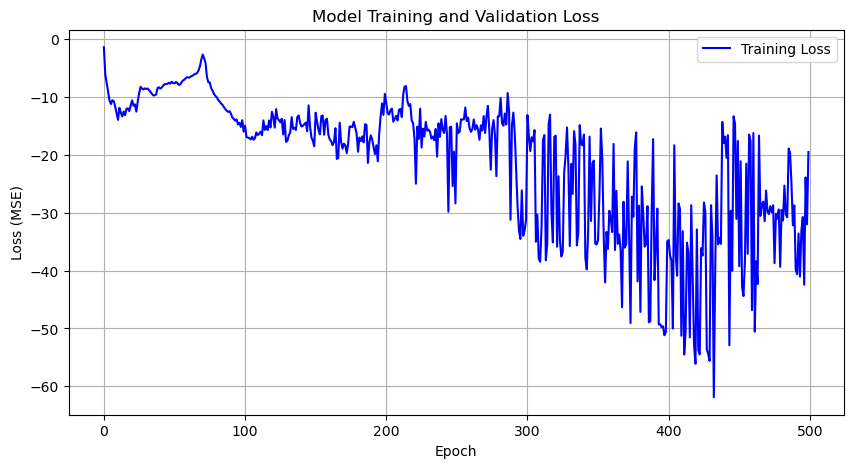

In [83]:
# ----------------------------------
# 9. Visualize Training Progress
# ----------------------------------

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(np.log(history.history['loss']), label='Training Loss', color='blue')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()



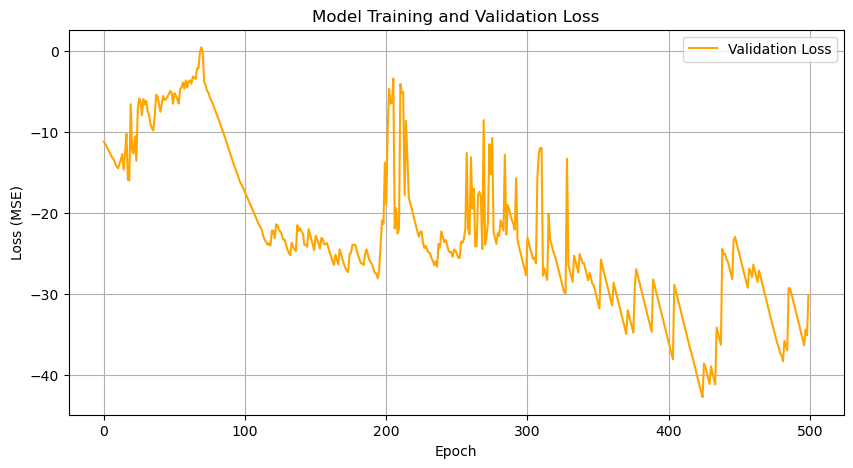

In [82]:


# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(np.log(history.history['val_loss']), label='Validation Loss', color='orange')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# # ----------------------------------
# # 10. Evaluate and Visualize Model Performance
# # ----------------------------------

# # Make predictions on the test set
# X_test_pred = model.predict(X_test_masked)  # Shape: (k_test,32,16,32)

# # Visualize original vs. reconstructed data for a sample
# sample_index = 0  # Change as needed (0 to k_test-1)

# # Original Distribution Data (Unmasked)
# original_distribution = np.sum(X_test[sample_index, 0, :, :, :], axis=2)  # Sum over energy levels => Shape: (32,16)

# # Reconstructed Distribution Data
# reconstructed_distribution = np.sum(X_test_pred[sample_index, :, :, :], axis=2)  # Sum over energy levels => Shape: (32,16)

# # Plotting
# plt.figure(figsize=(18, 6))

# # Plot Original
# plt.subplot(1, 2, 1)
# plt.imshow(original_distribution, aspect='auto', origin='lower', cmap='viridis')
# plt.title('Original Distribution')
# plt.xlabel('Theta Bins')
# plt.ylabel('Phi Bins')
# plt.colorbar(label='Intensity')

# # Plot Reconstructed
# plt.subplot(1, 2, 2)
# plt.imshow(reconstructed_distribution, aspect='auto', origin='lower', cmap='viridis')
# plt.title('Reconstructed Distribution')
# plt.xlabel('Theta Bins')
# plt.ylabel('Phi Bins')
# plt.colorbar(label='Intensity')

# plt.tight_layout()
# plt.show()

# print("\nEvaluation and visualization completed.")



In [ ]:
# ----------------------------------
# 11. Save the Trained Model (Optional)
# ----------------------------------

# Save the trained model
model.save('advanced_conv_lstm_attention_model_initial_7.h5')
print("Model saved to 'advanced_conv_lstm_attention_model_initial.h5'.")

# To load the model later, use:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('advanced_conv_lstm_attention_model_initial.h5')


In [25]:
# # ----------------------------------
# # Aurora Project: Initial Training Evaluation with RMSE and Moments-Based Loss
# # ----------------------------------

# import os
# import datetime
# import numpy as np
# import cdflib
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d
# import tensorflow as tf
# from tensorflow.keras.models import load_model
# from sklearn.metrics import mean_squared_error
# import random

# # Ensure reproducibility
# random.seed(42)
# np.random.seed(42)
# tf.random.set_seed(42)

# # ----------------------------------
# # 1. Define Paths to Data Folders
# # ----------------------------------

# # Update these paths based on your directory structure
# fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
# fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
# fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

# # Path to the pre-trained model
# pretrained_model_path = 'advanced_conv_lstm_attention_model_initial_7.h5'  # Update if different

# # Path to the test CDF files
# fgm_test_filepath = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm//test_fgm.cdf"          # Update with actual path
# fpi_dist_test_filepath = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//test_fpi_dist.cdf"    # Update with actual path
# fpi_moms_test_filepath = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//test_fpi_moms.cdf"    # Update with actual path

# # ----------------------------------
# # 2. Define Helper Functions
# # ----------------------------------

# def extract_timestamp(filename):
#     """
#     Extract timestamp from filename.
#     Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

#     Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
#     """
#     try:
#         parts = filename.split('_')
#         for part in parts:
#             if part.isdigit() and len(part) == 14:
#                 return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
#         raise ValueError("No valid timestamp found in filename")
#     except Exception as e:
#         print(f"Error extracting timestamp from filename: {filename} - {e}")
#         return None

# def load_fgm_data(filepath):
#     """Load magnetic field data from FGM CDF file."""
#     with cdflib.CDF(filepath) as fgm_cdf:
#         epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
#         b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
#     return epoch, b_gse

# def load_fpi_dist_data(filepath):
#     """Load distribution data from FPI (`des-dist`) CDF file."""
#     with cdflib.CDF(filepath) as fpi_cdf:
#         epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
#         dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
#         theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
#         phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
#         energy = fpi_cdf.varget('mms1_des_energy_brst')  # Energy levels
#     return epoch, dist_data, theta, phi, energy  # Return energy

# def load_fpi_moms_data(filepath):
#     """Load bulk velocity data from FPI (`des-moms`) CDF file."""
#     with cdflib.CDF(filepath) as moms_cdf:
#         epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
#         bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
#     return epoch, bulk_velocity

# def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
#     """Interpolate magnetic field data to match FPI timestamps."""
#     # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
#     b_gse = b_gse[:, :3]
#     interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
#     return interpolator(fpi_epoch)

# def calculate_pitch_angle(phi_bins, theta_bins, b_field):
#     """Calculate pitch angle distribution using look direction (phi, theta) and magnetic field."""
#     # Convert theta and phi to radians
#     theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
#     phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

#     # Create meshgrid for phi and theta
#     phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)

#     # Compute look direction unit vector components
#     look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
#     look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
#     look_direction_z = np.cos(theta_grid)

#     # Stack components to form the look direction vectors
#     look_direction = np.stack(
#         [look_direction_x, look_direction_y, look_direction_z],
#         axis=2
#     )  # Shape: (phi_bins, theta_bins, 3)

#     # Flatten look_direction for efficient computation
#     look_direction_flat = look_direction.reshape(-1, 3)  # Shape: (phi_bins * theta_bins, 3)

#     # Initialize the pitch angles array
#     time_steps = b_field.shape[0]
#     pitch_angles = np.zeros((time_steps, phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

#     # Iterate over each time step
#     for t in range(time_steps):
#         # Normalize magnetic field vector
#         b_vector = b_field[t, :3]  # Assuming b_field has shape (time_steps, 3)
#         b_magnitude = np.linalg.norm(b_vector)
#         if b_magnitude == 0:
#             b_unit = np.zeros(3)
#         else:
#             b_unit = b_vector / b_magnitude

#         # Compute dot product between look direction and magnetic field
#         v_dot_b = np.dot(look_direction_flat, b_unit)  # Shape: (phi_bins * theta_bins,)
#         v_dot_b = np.clip(v_dot_b, -1.0, 1.0)  # Ensure values are within valid range

#         # Calculate pitch angles in degrees
#         pitch_angles_flat = np.arccos(v_dot_b) * (180.0 / np.pi)

#         # Reshape back to (phi_bins, theta_bins)
#         pitch_angles[t] = pitch_angles_flat.reshape(phi_bins.size, theta_bins.size)

#     return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)

# def prepare_data(fgm_filepath, fpi_dist_filepath, fpi_moms_filepath):
#     """
#     Load and preprocess data from a single matched CDF file set.

#     Parameters:
#     - fgm_filepath: Path to the FGM CDF file.
#     - fpi_dist_filepath: Path to the FPI Distribution CDF file.
#     - fpi_moms_filepath: Path to the FPI Moments CDF file.

#     Returns:
#     - X_data: Preprocessed input data ready for model input. Shape: (time_steps, 1, phi_bins, theta_bins, energy_levels + 1)
#     - y_data: Corresponding target data for training. Shape: (time_steps, 32, 16, 32)
#     """
#     # Load FGM data
#     fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
#     print(f"Loaded FGM data from {fgm_filepath}.")

#     # Load FPI Distribution data
#     fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)
#     print(f"Loaded FPI Distribution data from {fpi_dist_filepath}.")

#     # Load FPI Moments data
#     moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
#     print(f"Loaded FPI Moments data from {fpi_moms_filepath}.")

#     # Interpolate magnetic field to match FPI timestamps
#     b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
#     print("Interpolated magnetic field data to match FPI timestamps.")

#     # Prepare phi_bins and theta_bins
#     if phi.ndim == 1:
#         phi_bins = phi.flatten()  # Shape: (phi_bins=32,)
#     elif phi.ndim == 2:
#         phi_bins = phi[0].flatten()
#         print("Phi has an extra time dimension. Extracted phi from the first time step.")
#     else:
#         raise ValueError("Unexpected shape for phi_bins.")

#     if theta.ndim == 1:
#         theta_bins = theta.flatten()  # Shape: (theta_bins=16,)
#     elif theta.ndim == 2:
#         theta_bins = theta[0].flatten()
#         print("Theta has an extra time dimension. Extracted theta from the first time step.")
#     else:
#         raise ValueError("Unexpected shape for theta_bins.")

#     # Verify shapes
#     print(f"Phi bins shape: {phi_bins.shape}")     # Expected: (32,)
#     print(f"Theta bins shape: {theta_bins.shape}") # Expected: (16,)

#     # Compute pitch angles using the provided function
#     pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
#     print("Calculated pitch angles.")

#     # Do not transpose pitch_angles; keep (time_steps, phi_bins, theta_bins)
#     print(f"pitch_angles shape: {pitch_angles.shape}")  # Should be (time_steps,32,16)

#     # Normalize pitch angles to [0, 1] for input to the model
#     pitch_angles_normalized = pitch_angles / 180.0  # Shape: (time_steps,32,16)

#     # Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)
#     # Original shape assumed: (time_steps, energy_levels=32, phi_bins=32, theta_bins=16)
#     # Desired shape: (time_steps, phi_bins=32, theta_bins=16, energy_levels=32)

#     # Verify current shape
#     if dist_data.ndim != 4:
#         raise ValueError("Distribution data should have 4 dimensions (time_steps, energy_levels, phi_bins, theta_bins).")

#     # Transpose if necessary
#     if dist_data.shape[1] == energy.size and dist_data.shape[2] == phi_bins.size and dist_data.shape[3] == theta_bins.size:
#         dist_data_transposed = dist_data  # (time_steps, phi_bins, theta_bins, energy_levels)
#         print("Transposed distribution data to shape (time_steps, phi_bins, theta_bins, energy_levels).")
#     else:
#         # If already in desired shape, no transpose
#         dist_data_transposed = dist_data
#         print("Distribution data is already in the desired shape.")

#     print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Should be (time_steps,32,16,32)

#     # Ensure that pitch_angles and dist_data_transposed have matching phi_bins and theta_bins
#     if pitch_angles_normalized.shape[1] != dist_data_transposed.shape[1] or \
#        pitch_angles_normalized.shape[2] != dist_data_transposed.shape[2]:
#         raise ValueError("Mismatch in phi_bins or theta_bins dimensions between pitch_angles and dist_data_transposed.")

#     # Expand pitch_angles to add a new feature (energy_levels +1)
#     pitch_angles_expanded = pitch_angles_normalized[..., np.newaxis]  # Shape: (time_steps,32,16,1)
#     print(f"Pitch Angles Expanded Shape: {pitch_angles_expanded.shape}")  # Shape: (time_steps,32,16,1)

#     # Concatenate distribution data and pitch angles along the energy_levels axis
#     X_data = np.concatenate((
#         dist_data_transposed,
#         pitch_angles_expanded
#     ), axis=3)  # Shape: (time_steps,32,16,33)
#     X_data = X_data.astype('float32')
#     print(f"Input Data Shape with Pitch Angles: {X_data.shape}")  # Should be (time_steps,32,16,33)

#     # Prepare targets (PSD data without pitch angles)
#     y_data = dist_data_transposed  # Shape: (time_steps,32,16,32)

#     # Reshape data to include time_steps=1 for model input
#     # Current X_data shape: (time_steps,32,16,33)
#     # Desired shape: (time_steps,1,32,16,33)
#     X_data = X_data.reshape((X_data.shape[0], 1, X_data.shape[1], X_data.shape[2], X_data.shape[3]))  # (time_steps,1,32,16,33)
#     print(f"Reshaped Input Data Shape: {X_data.shape}")  # (time_steps,1,32,16,33)

#     # Targets shape: (time_steps,32,16,32)
#     # For model training, targets should match model output shape: (time_steps,32,16,32)
#     # No need to reshape y_data
#     print(f"Target Data Shape: {y_data.shape}")  # (time_steps,32,16,32)

#     return X_data, y_data

# def calculate_moments(psd_data, skymap_name="Skymap"):
#     """
#     Calculate moments from PSD data using the skymaps library.

#     Parameters:
#     - psd_data: Numpy array of shape (samples, phi_bins, theta_bins, energy_levels)
#     - skymap_name: String identifier for the Skymap

#     Returns:
#     - moments: Moments calculated from the skymap
#     """
#     from skymaps.skymap import Skymap

#     # Transpose PSD data to match skymaps' expected input
#     # Assuming PSD data is in the shape (samples, phi_bins, theta_bins, energy_levels)
#     # Skymaps expects (time_steps, energy_levels, elevation, azimuth)
#     psd_transposed = psd_data.transpose(0, 3, 2, 1)  # (samples, energy_levels, theta_bins, phi_bins)

#     # Initialize Skymap object
#     skymap = Skymap(psd_transposed.shape[0], skymap_name, nen=psd_transposed.shape[1])
#     skymap.skymap = psd_transposed

#     # Calculate moments (e.g., density)
#     moments = skymap.momsTS  # This should return a structured array with different moments

#     return moments

# def compute_moments_loss(moments_actual, moments_predicted, moment_key='density'):
#     """
#     Compute the RMSE between actual and predicted moments.

#     Parameters:
#     - moments_actual: Moments from the actual test data.
#     - moments_predicted: Moments from the predicted test data.
#     - moment_key: The key corresponding to the desired moment (e.g., 'density').

#     Returns:
#     - moments_rmse: RMSE between actual and predicted moments.
#     """
#     # Extract the desired moment
#     actual_moment = moments_actual[moment_key]  # Shape: (samples,)
#     predicted_moment = moments_predicted[moment_key]  # Shape: (samples,)

#     # Compute RMSE
#     mse_moment = mean_squared_error(actual_moment, predicted_moment)
#     rmse_moment = np.sqrt(mse_moment)

#     return rmse_moment

# def evaluate_model_performance(y_test, y_pred):
#     """
#     Evaluate model performance using RMSE and moments-based loss.

#     Parameters:
#     - y_test: Actual PSD data. Shape: (samples, phi_bins, theta_bins, energy_levels)
#     - y_pred: Predicted PSD data. Shape: (samples, phi_bins, theta_bins, energy_levels)

#     Returns:
#     - Dictionary containing RMSE and moments-based loss.
#     """
#     # Calculate RMSE
#     y_test_flat = y_test.reshape((y_test.shape[0], -1))
#     y_pred_flat = y_pred.reshape((y_pred.shape[0], -1))
#     rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))

#     # Calculate moments
#     moments_test = calculate_moments(y_test, skymap_name="Actual_Test_Skymap")
#     moments_pred = calculate_moments(y_pred, skymap_name="Predicted_Test_Skymap")

#     # Determine available moments
#     available_moments = moments_test.dtype.names
#     print(f"Available moments: {available_moments}")

#     # Compute moments-based loss for each available moment
#     moments_losses = {}
#     for moment in available_moments:
#         try:
#             loss = compute_moments_loss(moments_test, moments_pred, moment_key=moment)
#             moments_losses[f"{moment}_rmse"] = loss
#         except KeyError:
#             print(f"Moment '{moment}' not found in moments data.")

#     # Combine metrics
#     evaluation_metrics = {
#         'RMSE': rmse,
#     }
#     evaluation_metrics.update(moments_losses)

#     return evaluation_metrics

# def plot_moments(moments_actual, moments_predicted, moment_key='density'):
#     """
#     Plot the actual and predicted moments over time.

#     Parameters:
#     - moments_actual: Moments from the actual test data.
#     - moments_predicted: Moments from the predicted test data.
#     - moment_key: The key corresponding to the desired moment (e.g., 'density').

#     Returns:
#     - None
#     """
#     import matplotlib.pyplot as plt

#     plt.figure(figsize=(15, 5))
#     plt.plot(moments_actual[moment_key], label='Actual')
#     plt.plot(moments_predicted[moment_key], label='Predicted', alpha=0.7)
#     plt.title(f'{moment_key.capitalize()} Moments Over Time')
#     plt.xlabel('Time Steps')
#     plt.ylabel(moment_key.capitalize())
#     plt.legend()
#     plt.show()

# def plot_psd_sample(y_actual, y_reconstructed, sample_idx=0):
#     """
#     Plot the original and reconstructed PSD distributions for a specific sample.

#     Parameters:
#     - y_actual: Actual PSD data. Shape: (32, 16, 32)
#     - y_reconstructed: Reconstructed PSD data. Shape: (32, 16, 32)
#     - sample_idx: Index of the sample to plot.

#     Returns:
#     - None
#     """
#     plt.figure(figsize=(18, 6))

#     # Plot Original Distribution (Sum over energy levels)
#     plt.subplot(1, 2, 1)
#     plt.imshow(np.sum(y_actual, axis=2), aspect='auto', origin='lower', cmap='viridis')
#     plt.title('Original Distribution')
#     plt.xlabel('Theta Bins')
#     plt.ylabel('Phi Bins')
#     plt.colorbar(label='Intensity')

#     # Plot Reconstructed Distribution (Sum over energy levels)
#     plt.subplot(1, 2, 2)
#     plt.imshow(np.sum(y_reconstructed, axis=2), aspect='auto', origin='lower', cmap='viridis')
#     plt.title('Reconstructed Distribution')
#     plt.xlabel('Theta Bins')
#     plt.ylabel('Phi Bins')
#     plt.colorbar(label='Intensity')

#     plt.tight_layout()
#     plt.show()



In [26]:
# # ----------------------------------
# # 3. Load the Pre-Trained Model
# # ----------------------------------

# # try:
# #     pretrained_model = load_model(pretrained_model_path)
# #     print(f"Pre-trained model loaded successfully from '{pretrained_model_path}'.")
# # except Exception as e:
# #     print(f"Error loading pre-trained model: {e}")
# #     raise

# # ----------------------------------
# # 4. Prepare the Test Set
# # ----------------------------------

# def prepare_test_set(fgm_test_filepath, fpi_dist_test_filepath, fpi_moms_test_filepath):
#     """
#     Prepare the test set data.

#     Parameters:
#     - fgm_test_filepath: Path to the FGM test CDF file.
#     - fpi_dist_test_filepath: Path to the FPI Distribution test CDF file.
#     - fpi_moms_test_filepath: Path to the FPI Moments test CDF file.

#     Returns:
#     - X_test: Preprocessed test input data. Shape: (time_steps, 1, 32, 16, 33)
#     - y_test: Corresponding test target data. Shape: (time_steps, 32, 16, 32)
#     """
#     X_test, y_test = prepare_data(fgm_test_filepath, fpi_dist_test_filepath, fpi_moms_test_filepath)
#     print("Prepared test set data.")
#     return X_test, y_test

# # Prepare your test data
# X_test, y_test = prepare_test_set(fgm_test_filepath, fpi_dist_test_filepath, fpi_moms_test_filepath)



FileNotFoundError: C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\data\mms1\fgm\test_fgm.cdf not found

In [ ]:
# # ----------------------------------
# # 5. Make Predictions on the Test Set
# # ----------------------------------

# print("Making predictions on the test set...")
# # y_pred = pretrained_model.predict(X_test, batch_size=32)
# y_pred = model.predict(X_test, batch_size=32)
# print("Predictions completed.")

# # ----------------------------------
# # 6. Evaluate Model Performance
# # ----------------------------------

# def evaluate_and_visualize(model, X_test, y_test, sample_index=0):
#     """
#     Evaluate the model on the test set and visualize a sample reconstruction.

#     Parameters:
#     - model: Trained Keras model.
#     - X_test: Test input data. Shape: (samples, 1, 32, 16, 33)
#     - y_test: Test target data. Shape: (samples, 32, 16, 32)
#     - sample_index: Index of the sample to visualize.

#     Returns:
#     - None
#     """
#     # Make predictions
#     y_pred = model.predict(X_test, batch_size=32)
#     print("Made predictions on the test set.")

#     # Evaluate performance
#     evaluation_results = evaluate_model_performance(y_test, y_pred)

#     # Print evaluation metrics
#     print("\nModel Evaluation Results:")
#     for metric, value in evaluation_results.items():
#         print(f"{metric}: {value}")

#     # Calculate moments for actual and predicted data
#     moments_test = calculate_moments(y_test, skymap_name="Actual_Test_Skymap")
#     moments_pred = calculate_moments(y_pred, skymap_name="Predicted_Test_Skymap")

#     # Plot moments-based loss for density
#     if 'density' in moments_test.dtype.names and 'density' in moments_pred.dtype.names:
#         plot_moments(
#             moments_actual=moments_test,
#             moments_predicted=moments_pred,
#             moment_key='density'
#         )
#     else:
#         print("Density moment not found in moments data.")

#     # Visualize a specific sample's PSD
#     if X_test.shape[0] > sample_index:
#         plot_psd_sample(
#             y_actual=y_test[sample_index],
#             y_reconstructed=y_pred[sample_index],
#             sample_idx=sample_index
#         )
#     else:
#         print(f"Sample index {sample_index} is out of bounds for the test set.")

# # Perform evaluation and visualization
# evaluate_and_visualize(pretrained_model, X_test, y_test, sample_index=0)

# # ----------------------------------
# # 7. Notes and Further Instructions
# # ----------------------------------

# # 1. **Preparing the Test Set:**
# #    - Ensure that you have separate CDF files for your test set.
# #    - Update the `fgm_test_filepath`, `fpi_dist_test_filepath`, and `fpi_moms_test_filepath` variables with the actual paths to your test CDF files.

# # 2. **Moments Calculation:**
# #    - The `skymaps` library is used for calculating moments. Ensure it's installed and properly configured.
# #    - The `moment_key` (e.g., `'density'`) should correspond to the actual moments available in your data. You can inspect available moments using `print(moments_test.dtype.names)`.

# # 3. **Visualization:**
# #    - The script includes functions to plot moments over time and to visualize a specific sample's PSD distribution.
# #    - Adjust `sample_index` as needed to visualize different samples.

# # 4. **Error Handling:**
# #    - The script includes basic error messages for missing timestamps and mismatched data shapes. Ensure your data files follow the expected naming conventions and data formats.

# # 5. **Model Compatibility:**
# #    - Ensure that the architecture of the pre-trained model matches the input data dimensions. The input shape in the script is `(time_steps, 1, 32, 16, 33)`, which should align with your model's expected input.

# # 6. **Further Enhancements:**
# #    - You can extend the `evaluate_model_performance` function to include additional moments or other evaluation metrics as needed.
# #    - Implement logging mechanisms to track the evaluation process more effectively.

# # ----------------------------------
# # End of Evaluation Script
# # -------------------------------

# Fine tuning

In [61]:
# ----------------------------------
# Aurora Project: Fine-Tuning Advanced Autoencoder on Multiple CDF Data Sets
# ----------------------------------

import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D, Reshape, LSTM, Dense, BatchNormalization,
    Dropout, Attention, GlobalAveragePooling1D, Lambda
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
import random

# ----------------------------------
# 1. Set Random Seeds for Reproducibility
# ----------------------------------
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------------
# 2. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders (Update these paths as per your directory structure)
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

    Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
        theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
        phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
        energy = fpi_cdf.varget('mms1_des_energy_brst')  # Energy levels
    return epoch, dist_data, theta, phi, energy  # Return energy

def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
    return epoch, bulk_velocity

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """Calculate pitch angle distribution using look direction (phi, theta) and magnetic field."""
    # Convert theta and phi to radians
    theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
    phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

    # Create meshgrid for phi and theta
    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)

    # Compute look direction unit vector components
    look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
    look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
    look_direction_z = np.cos(theta_grid)

    # Stack components to form the look direction vectors
    look_direction = np.stack(
        [look_direction_x, look_direction_y, look_direction_z],
        axis=2
    )  # Shape: (phi_bins, theta_bins, 3)

    # Flatten look_direction for efficient computation
    look_direction_flat = look_direction.reshape(-1, 3)  # Shape: (phi_bins * theta_bins, 3)

    # Initialize the pitch angles array
    time_steps = b_field.shape[0]
    pitch_angles = np.zeros((time_steps, phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

    # Iterate over each time step
    for t in range(time_steps):
        # Normalize magnetic field vector
        b_vector = b_field[t, :3]  # Assuming b_field has shape (time_steps, 3)
        b_magnitude = np.linalg.norm(b_vector)
        if b_magnitude == 0:
            b_unit = np.zeros(3)
        else:
            b_unit = b_vector / b_magnitude

        # Compute dot product between look direction and magnetic field
        v_dot_b = np.dot(look_direction_flat, b_unit)  # Shape: (phi_bins * theta_bins,)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)  # Ensure values are within valid range

        # Calculate pitch angles in degrees
        pitch_angles_flat = np.arccos(v_dot_b) * (180.0 / np.pi)

        # Reshape back to (phi_bins, theta_bins)
        pitch_angles[t] = pitch_angles_flat.reshape(phi_bins.size, theta_bins.size)

    return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

def prepare_data(fgm_filepath, fpi_dist_filepath, fpi_moms_filepath):
    """
    Load and preprocess data from a single matched CDF file set.
    
    Parameters:
    - fgm_filepath: Path to the FGM CDF file.
    - fpi_dist_filepath: Path to the FPI Distribution CDF file.
    - fpi_moms_filepath: Path to the FPI Moments CDF file.
    
    Returns:
    - X_data: Preprocessed input data ready for model input. Shape: (time_steps, 1, phi_bins, theta_bins, energy_levels + 1)
    - y_data: Corresponding target data for training. Shape: (time_steps, 32, 16, 32)
    """
    # Load FGM data
    fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
    print(f"Loaded FGM data from {fgm_filepath}.")
    
    # Load FPI Distribution data
    fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)
    print(f"Loaded FPI Distribution data from {fpi_dist_filepath}.")
    
    # Load FPI Moments data
    moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
    print(f"Loaded FPI Moments data from {fpi_moms_filepath}.")
    
    # Interpolate magnetic field to match FPI timestamps
    b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
    print("Interpolated magnetic field data to match FPI timestamps.")
    
    # Prepare phi_bins and theta_bins
    if phi.ndim == 1:
        phi_bins = phi.flatten()  # Shape: (phi_bins=32,)
    elif phi.ndim == 2:
        phi_bins = phi[0].flatten()
        print("Phi has an extra time dimension. Extracted phi from the first time step.")
    else:
        raise ValueError("Unexpected shape for phi_bins.")
    
    if theta.ndim == 1:
        theta_bins = theta.flatten()  # Shape: (theta_bins=16,)
    elif theta.ndim == 2:
        theta_bins = theta[0].flatten()
        print("Theta has an extra time dimension. Extracted theta from the first time step.")
    else:
        raise ValueError("Unexpected shape for theta_bins.")
    
    # Verify shapes
    print(f"Phi bins shape: {phi_bins.shape}")     # Expected: (32,)
    print(f"Theta bins shape: {theta_bins.shape}") # Expected: (16,)
    
    # Compute pitch angles using the provided function
    pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
    print("Calculated pitch angles.")
    
    # Do not transpose pitch_angles; keep (time_steps, phi_bins, theta_bins)
    print(f"pitch_angles shape: {pitch_angles.shape}")  # Should be (time_steps,32,16)
    
    # Normalize pitch angles to [0, 1] for input to the model
    pitch_angles_normalized = pitch_angles / 180.0  # Shape: (time_steps,32,16)
    
    # Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)
    # Original shape assumed: (time_steps, energy_levels=32, phi_bins=32, theta_bins=16)
    # Desired shape: (time_steps, phi_bins=32, theta_bins=16, energy_levels=32)
    
    # Verify current shape
    if dist_data.ndim != 4:
        raise ValueError("Distribution data should have 4 dimensions (time_steps, energy_levels, phi_bins, theta_bins).")
    
    # Transpose if necessary
    if dist_data.shape[1] == energy.size and dist_data.shape[2] == phi_bins.size and dist_data.shape[3] == theta_bins.size:
        dist_data_transposed = dist_data.transpose(0, 2, 3, 1)  # (time_steps, phi_bins, theta_bins, energy_levels)
        print("Transposed distribution data to shape (time_steps, phi_bins, theta_bins, energy_levels).")
    else:
        # If already in desired shape, no transpose
        dist_data_transposed = dist_data
        print("Distribution data is already in the desired shape.")
    
    print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Should be (time_steps,32,16,32)
    
    # Ensure that pitch_angles and dist_data_transposed have matching phi_bins and theta_bins
    if pitch_angles_normalized.shape[1] != dist_data_transposed.shape[1] or \
       pitch_angles_normalized.shape[2] != dist_data_transposed.shape[2]:
        raise ValueError("Mismatch in phi_bins or theta_bins dimensions between pitch_angles and dist_data_transposed.")
    
    # Expand pitch_angles to add a new feature (energy_levels +1)
    pitch_angles_expanded = pitch_angles_normalized[..., np.newaxis]  # Shape: (time_steps,32,16,1)
    print(f"Pitch Angles Expanded Shape: {pitch_angles_expanded.shape}")  # Shape: (time_steps,32,16,1)
    
    # Concatenate distribution data and pitch angles along the energy_levels axis
    X_data = np.concatenate((
        dist_data_transposed,
        pitch_angles_expanded
    ), axis=3)  # Shape: (time_steps,32,16,33)
    X_data = X_data.astype('float32')
    print(f"Input Data Shape with Pitch Angles: {X_data.shape}")  # Should be (time_steps,32,16,33)
    
    # Prepare targets (PSD data without pitch angles)
    y_data = dist_data_transposed  # Shape: (time_steps,32,16,32)
    
    # Reshape data to include time_steps=1 for model input
    # Current X_data shape: (time_steps,32,16,33)
    # Desired shape: (time_steps,1,32,16,33)
    X_data = X_data.reshape((X_data.shape[0], 1, X_data.shape[1], X_data.shape[2], X_data.shape[3]))  # (time_steps,1,32,16,33)
    print(f"Reshaped Input Data Shape: {X_data.shape}")  # (time_steps,1,32,16,33)
    
    # Targets shape: (time_steps,32,16,32)
    # For model training, targets should match model output shape: (time_steps,32,16,32)
    # No need to reshape y_data
    print(f"Target Data Shape: {y_data.shape}")  # (time_steps,32,16,32)
    
    return X_data, y_data

def fine_tune_model_on_multiple_cdf_sets(matched_files, fpi_dist_folder, fgm_folder, fpi_moms_folder, model, fine_tune_epochs=10, batch_size=32):
    """
    Fine-tune the pre-trained model on multiple matched CDF file sets, excluding the first one.
    
    Parameters:
    - matched_files: List of tuples containing matched CDF file names.
    - fpi_dist_folder: Directory containing FPI Distribution CDF files.
    - fgm_folder: Directory containing FGM CDF files.
    - fpi_moms_folder: Directory containing FPI Moments CDF files.
    - model: Pre-trained Keras model to be fine-tuned.
    - fine_tune_epochs: Number of epochs for fine-tuning on each file set.
    - batch_size: Batch size for training.
    
    Returns:
    - None
    """
    # Exclude the first matched set (already trained on)
    sets_to_finetune = matched_files
    print(f"\nTotal matched file sets to fine-tune on: {len(sets_to_finetune)}")
    
    for idx, (timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename) in enumerate(sets_to_finetune, start=2):
        print(f"\n--- Fine-Tuning on CDF File Set {idx}/{len(matched_files)} ---")
        print(f"Timestamp: {timestamp}")
        print(f"FPI Distribution File: {fpi_dist_filename}")
        print(f"FGM File: {fgm_filename}")
        print(f"FPI Moments File: {fpi_moms_filename}")
        
        # Construct full file paths
        fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
        fgm_filepath = os.path.join(fgm_folder, fgm_filename)
        fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)
        
        # Prepare data
        X_data, y_data = prepare_data(fgm_filepath, fpi_dist_filepath, fpi_moms_filepath)
        
        # Split into fine-tuning training and validation sets (e.g., 80% train, 20% val)
        total_time_steps = X_data.shape[0]
        n_finetune_train = int(0.8 * total_time_steps)
        k_finetune_val = total_time_steps - n_finetune_train
        
        X_finetune_train = X_data[:n_finetune_train]
        y_finetune_train = y_data[:n_finetune_train]
        
        X_finetune_val = X_data[n_finetune_train:]
        y_finetune_val = y_data[n_finetune_train:]
        
        print(f"Fine-Tuning Training Data Shape: {X_finetune_train.shape}")  # (n_finetune_train,1,32,16,33)
        print(f"Fine-Tuning Validation Data Shape: {X_finetune_val.shape}")  # (k_finetune_val,1,32,16,33)
        
        # Define callbacks
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
        
        checkpoint = ModelCheckpoint(
            f'fine_tuned_model_set_{idx}.h5',
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=1
        )
        
        # Fine-Tune the Model on Current CDF File Set
        history = model.fit(
            X_finetune_train, y_finetune_train,
            epochs=fine_tune_epochs,
            batch_size=batch_size,
            shuffle=False,  # Preserve time dependency
            validation_data=(X_finetune_val, y_finetune_val),
            callbacks=[early_stopping, checkpoint]
        )
        
        print(f"Fine-tuning on CDF File Set {idx} completed.")
        
        # Optionally, save the training history for later analysis
        np.save(f'history_finetune_set_{idx}.npy', history.history)
    
    print("\nAll fine-tuning steps completed.")


In [73]:
from tensorflow.keras.models import load_model
loaded_model = load_model('advanced_conv_lstm_attention_model_initial_7.h5')

SystemError: Exception encountered when calling layer "lambda_1" (type Lambda).

unknown opcode

Call arguments received by layer "lambda_1" (type Lambda):
  • inputs=tf.Tensor(shape=(None, None, 2, 2, 512), dtype=float32)
  • mask=None
  • training=None

In [75]:
# Perform file matching using the existing match_files function
def freeze_last_layers(model, num_conv_layers_to_freeze=1, num_lstm_layers_to_freeze=1):
    """
    Freeze the last `num_conv_layers_to_freeze` Conv3D layers and the last `num_lstm_layers_to_freeze` LSTM layers.

    Parameters:
    - model: Keras model to modify.
    - num_conv_layers_to_freeze: Number of Conv3D layers from the end to freeze.
    - num_lstm_layers_to_freeze: Number of LSTM layers from the end to freeze.

    Returns:
    - None
    """
    # Identify Conv3D and LSTM layers
    conv3d_layers = [layer for layer in model.layers if isinstance(layer, Conv3D)]
    lstm_layers = [layer for layer in model.layers if isinstance(layer, LSTM)]

    print(f"Total Conv3D layers: {len(conv3d_layers)}")
    print(f"Total LSTM layers: {len(lstm_layers)}")

    # Freeze the last `num_conv_layers_to_freeze` Conv3D layers
    for layer in conv3d_layers[-1:]:
        layer.trainable = False
        print(f"Frozen Conv3D layer: {layer.name}")

    # Freeze the last `num_lstm_layers_to_freeze` LSTM layers
    for layer in lstm_layers[-1:]:
        layer.trainable = False
        print(f"Frozen LSTM layer: {layer.name}")

    # Optionally, you can print the trainable status of all layers
    for layer in model.layers:
        print(f"Layer {layer.name} trainable: {layer.trainable}")

# Example: Freeze the last 1 Conv3D layer and the last 1 LSTM layer
freeze_last_layers(model, num_conv_layers_to_freeze=1, num_lstm_layers_to_freeze=1)

# ----------------------------------
# 5. Compile the Model After Freezing Layers
# ----------------------------------

# It's crucial to compile the model after setting layer.trainable
model.compile(optimizer="adam", 
                         loss='mean_squared_error')
print("\nModel compiled for fine-tuning with a lower learning rate.")

Total Conv3D layers: 4
Total LSTM layers: 3
Frozen Conv3D layer: conv3d_7
Frozen LSTM layer: lstm_5
Layer input_layer trainable: True
Layer conv3d_4 trainable: True
Layer batch_normalization_8 trainable: True
Layer max_pooling3d_4 trainable: True
Layer conv3d_5 trainable: True
Layer batch_normalization_9 trainable: True
Layer max_pooling3d_5 trainable: True
Layer conv3d_6 trainable: True
Layer batch_normalization_10 trainable: True
Layer max_pooling3d_6 trainable: True
Layer conv3d_7 trainable: False
Layer batch_normalization_11 trainable: True
Layer max_pooling3d_7 trainable: True
Layer lambda_1 trainable: True
Layer lstm_3 trainable: True
Layer batch_normalization_12 trainable: True
Layer dropout_2 trainable: True
Layer lstm_4 trainable: True
Layer batch_normalization_13 trainable: True
Layer dropout_3 trainable: True
Layer lstm_5 trainable: False
Layer batch_normalization_14 trainable: True
Layer attention_2 trainable: True
Layer attention_3 trainable: True
Layer global_average_pool

In [76]:
fine_tune_model_on_multiple_cdf_sets(matched_files,fpi_dist_folder,fgm_folder,fpi_moms_folder,model,100,32)


Total matched file sets to fine-tune on: 4

--- Fine-Tuning on CDF File Set 2/5 ---
Timestamp: 2024-03-01 23:09:53
FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf
FGM File: mms1_fgm_brst_l2_20240301230953_v5.441.0.cdf
FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230953_v3.4.0.cdf
Loaded FGM data from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm\mms1_fgm_brst_l2_20240301230953_v5.441.0.cdf.
Loaded FPI Distribution data from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01\mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf.
Loaded FPI Moments data from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01\mms1_fpi_brst_l2_des-moms_20240301230953_v3.4.0.cdf.
Interpolated magnetic field data to match FPI timestamps.
Phi has an extra time dimension. Extracted phi from the first time step.
Phi bins shape:

C:\Users\ryane\anaconda3\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/100
125/125 [==============================] - ETA: 0s - loss: 4.3182e-11
Epoch 2: val_loss did not improve from 0.00000
125/125 [==============================] - 16s 130ms/step - loss: 4.3182e-11 - val_loss: 3.3617e-15
Epoch 3/100
125/125 [==============================] - ETA: 0s - loss: 2.1906e-13
Epoch 3: val_loss did not improve from 0.00000
125/125 [==============================] - 16s 131ms/step - loss: 2.1906e-13 - val_loss: 5.9057e-12
Epoch 4/100
125/125 [==============================] - ETA: 0s - loss: 5.5814e-13
Epoch 4: val_loss did not improve from 0.00000
125/125 [==============================] - 16s 132ms/step - loss: 5.5814e-13 - val_loss: 1.1341e-10
Epoch 5/100
125/125 [==============================] - ETA: 0s - loss: 3.4055e-08
Epoch 5: val_loss did not improve from 0.00000
125/125 [==============================] - 16s 131ms/step - loss: 3.4055e-08 - val_loss: 2.1864e-12
Epoch 6/100
125/125 [==============================] - ETA: 0s - loss: 6.4559e-09
Ep

117/117 [==============================] - 15s 131ms/step - loss: 8.2713e-10 - val_loss: 2.5207e-06
Fine-tuning on CDF File Set 4 completed.

--- Fine-Tuning on CDF File Set 5/5 ---
Timestamp: 2024-03-01 23:27:03
FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301232703_v3.4.0.cdf
FGM File: mms1_fgm_brst_l2_20240301232703_v5.441.0.cdf
FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301232703_v3.4.0.cdf
Loaded FGM data from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm\mms1_fgm_brst_l2_20240301232703_v5.441.0.cdf.
Loaded FPI Distribution data from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01\mms1_fpi_brst_l2_des-dist_20240301232703_v3.4.0.cdf.
Loaded FPI Moments data from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01\mms1_fpi_brst_l2_des-moms_20240301232703_v3.4.0.cdf.
Interpolated magnetic field data to match FPI tim

In [ ]:
def evaluate_and_visualize(model, X_test, y_test, sample_index=0):
    """
    Evaluate the model on the test set and visualize a sample reconstruction.
    
    Parameters:
    - model: Trained Keras model.
    - X_test: Test input data. Shape: (samples, 1, 32, 16, 33)
    - y_test: Test target data. Shape: (samples, 32, 16, 32)
    - sample_index: Index of the sample to visualize.
    
    Returns:
    - None
    """
    # Evaluate the model on the test set
    test_loss, test_mae = model.evaluate(X_test, y_test, batch_size=32)
    print(f"Test Loss (MSE): {test_loss}")
    print(f"Test MAE: {test_mae}")
    
    # Predict on a specific sample
    predicted_psd = model.predict(X_test[sample_index:sample_index+1])  # Shape: (1,32,16,32)
    predicted_psd = predicted_psd[0]  # Shape: (32,16,32)
    
    # Original PSD
    original_psd = y_test[sample_index]  # Shape: (32,16,32)
    
    # Plotting
    plt.figure(figsize=(18, 6))
    
    # Plot Original Distribution (Sum over energy levels)
    plt.subplot(1, 2, 1)
    plt.imshow(np.sum(original_psd, axis=2), aspect='auto', origin='lower', cmap='viridis')
    plt.title('Original Distribution')
    plt.xlabel('Theta Bins')
    plt.ylabel('Phi Bins')
    plt.colorbar(label='Intensity')
    
    # Plot Reconstructed Distribution (Sum over energy levels)
    plt.subplot(1, 2, 2)
    plt.imshow(np.sum(predicted_psd, axis=2), aspect='auto', origin='lower', cmap='viridis')
    plt.title('Reconstructed Distribution')
    plt.xlabel('Theta Bins')
    plt.ylabel('Phi Bins')
    plt.colorbar(label='Intensity')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming you have a separate test set prepared as X_test and y_test
# evaluate_and_visualize(pretrained_model, X_test, y_test, sample_index=0)


In [77]:
model.summary()

Model: "AdvancedConvLSTMAttentionModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling3d_4 (MaxPoolin  (None, None, 16, 8, 64)      0         [

In [80]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Reshape, TimeDistributed
import os

# ===========================================
# Step 1: Verify the Active Model
# ===========================================

# Assuming your active model variable is named 'model'
# If it's named differently, replace 'model' with the correct variable name.

print("Verifying the active model...")
model.summary()
print("\n")

# ===========================================
# Step 2: Define the Function to Replace Lambda
# ===========================================

def replace_lambda_with_time_distributed_reshape(original_model, 
                                                lambda_layer_name='lambda_1', 
                                                reshape_layer_name='reshape_lstm', 
                                                target_shape=(2048,)):
    """
    Rebuilds the model by replacing the specified Lambda layer with a TimeDistributed Reshape layer.

    Parameters:
    - original_model: The original Keras model.
    - lambda_layer_name: The name of the Lambda layer to replace ('lambda_1' by default).
    - reshape_layer_name: The name for the new Reshape layer ('reshape_lstm' by default).
    - target_shape: The target shape for the Reshape layer.

    Returns:
    - new_model: The rebuilt Keras model with the Lambda layer replaced.
    """
    # Dictionary to map original layer names to their corresponding outputs in the new model
    layer_output_map = {}

    # Iterate through each layer in the original model
    for layer in original_model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            # For InputLayer, simply add it to the new model
            layer_output_map[layer.name] = layer.output
            continue

        # Get the input tensors for the current layer
        inbound_layers = []
        for node in layer._inbound_nodes:
            # node.inbound_layers can be a single layer or a list of layers
            inbound = node.inbound_layers
            if isinstance(inbound, list):
                inbound_layers.extend(inbound)
            else:
                inbound_layers.append(inbound)

        # Fetch the corresponding outputs from the new model
        if len(inbound_layers) == 1:
            inbound_output = layer_output_map[inbound_layers[0].name]
        else:
            # If multiple inputs, create a list of inputs
            inbound_output = [layer_output_map[in_layer.name] for in_layer in inbound_layers]

        if layer.name == lambda_layer_name:
            # Replace Lambda layer with TimeDistributed Reshape layer
            reshaped = TimeDistributed(Reshape(target_shape=target_shape, name=reshape_layer_name))(inbound_output)
            layer_output_map[layer.name] = reshaped
            print(f"Replaced Lambda layer '{lambda_layer_name}' with TimeDistributed Reshape layer '{reshape_layer_name}'.")
        else:
            # Recreate the layer from its config
            new_layer = layer.__class__.from_config(layer.get_config())
            # Apply the layer to its input(s)
            new_output = new_layer(inbound_output)
            layer_output_map[layer.name] = new_output

    # Define the new model
    new_model = Model(inputs=original_model.input, 
                      outputs=layer_output_map[original_model.layers[-1].name])
    return new_model

# ===========================================
# Step 3: Replace the Lambda Layer
# ===========================================

print("Replacing the Lambda layer with a TimeDistributed Reshape layer...")
new_model = replace_lambda_with_time_distributed_reshape(
    original_model=model,
    lambda_layer_name='lambda_1',
    reshape_layer_name='reshape_lstm',
    target_shape=(2048,)
)
print("Modified model created successfully.\n")
new_model.summary()
print("\n")

# ===========================================
# Step 4: Transfer Weights to the New Model
# ===========================================

def transfer_weights(original_model, new_model):
    """
    Transfers weights from the original model to the new model based on layer names.

    Parameters:
    - original_model: The original Keras model.
    - new_model: The new Keras model with modified architecture.

    Returns:
    - None
    """
    print("Transferring weights from the original model to the new model...")
    for layer in original_model.layers:
        if layer.name == 'lambda_1':
            # Skip the Lambda layer as it has been replaced
            continue
        try:
            # Get the corresponding layer in the new model
            new_layer = new_model.get_layer(name=layer.name)
            # Set weights
            new_layer.set_weights(layer.get_weights())
            print(f"Transferred weights for layer: '{layer.name}'")
        except Exception as e:
            print(f"Skipping layer '{layer.name}'. Could not transfer weights. Error: {e}")

    print("Weight transfer complete.\n")

# Transfer the weights
transfer_weights(original_model=model, new_model=new_model)

# ===========================================
# Step 5: Save the Modified Model
# ===========================================

# Define the path to save the modified model
modified_model_path = r"C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\fine_tuned_model_set_5_no_lambda.h5"

print(f"Saving the modified model to: {modified_model_path}")
new_model.save(modified_model_path)
print("Modified model saved successfully without the Lambda layer.\n")

# ===========================================
# Step 6: Verify the Modified Model (Optional)
# ===========================================

# To verify, you can load the saved model in a new script or environment without the custom function
# Here's how you can do it within the same script

print("Verifying the saved modified model by loading it...")
try:
    loaded_modified_model = tf.keras.models.load_model(modified_model_path)
    print("Modified model loaded successfully.")
    loaded_modified_model.summary()
except Exception as e:
    print(f"Error loading the modified model: {e}")


Verifying the active model...
Model: "AdvancedConvLSTMAttentionModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling3d_4 (MaxPoolin  (None, Non

__________________________________________________________________________________________________


Replacing the Lambda layer with a TimeDistributed Reshape layer...
Replaced Lambda layer 'lambda_1' with TimeDistributed Reshape layer 'reshape_lstm'.
Modified model created successfully.

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 c

                                                                                                  
Total params: 13118848 (50.04 MB)
Trainable params: 9345792 (35.65 MB)
Non-trainable params: 3773056 (14.39 MB)
__________________________________________________________________________________________________


Transferring weights from the original model to the new model...
Transferred weights for layer: 'input_layer'
Transferred weights for layer: 'conv3d_4'
Transferred weights for layer: 'batch_normalization_8'
Transferred weights for layer: 'max_pooling3d_4'
Transferred weights for layer: 'conv3d_5'
Transferred weights for layer: 'batch_normalization_9'
Transferred weights for layer: 'max_pooling3d_5'
Transferred weights for layer: 'conv3d_6'
Transferred weights for layer: 'batch_normalization_10'
Transferred weights for layer: 'max_pooling3d_6'
Transferred weights for layer: 'conv3d_7'
Transferred weights for layer: 'batch_normalization_11'
Transferred weights for layer: 'max_pooli

C:\Users\ryane\anaconda3\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modified model loaded successfully.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling3d_4 (MaxPoolin  (None, None, 16, 8, 64)      

Total params: 13118848 (50.04 MB)
Trainable params: 9345792 (35.65 MB)
Non-trainable params: 3773056 (14.39 MB)
__________________________________________________________________________________________________


In [81]:
# Define the path to save the modified model
modified_model_path = r"C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\model.h5"

print(f"Saving the modified model to: {modified_model_path}")
new_model.save(modified_model_path)
print("Modified model saved successfully without the Lambda layer.\n")

# ===========================================
# Step 6: Verify the Modified Model (Optional)
# ===========================================

# To verify, you can load the saved model in a new script or environment without the custom function
# Here's how you can do it within the same script

print("Verifying the saved modified model by loading it...")
try:
    loaded_modified_model = tf.keras.models.load_model(modified_model_path)
    print("Modified model loaded successfully.")
    loaded_modified_model.summary()
except Exception as e:
    print(f"Error loading the modified model: {e}")


Saving the modified model to: C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\model.h5
Modified model saved successfully without the Lambda layer.

Verifying the saved modified model by loading it...
Modified model loaded successfully.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                               

 reshape_1 (Reshape)         (None, 32, 16, 32)           0         ['batch_normalization_15[0][0]
                                                                    ']                            
                                                                                                  
Total params: 13118848 (50.04 MB)
Trainable params: 9345792 (35.65 MB)
Non-trainable params: 3773056 (14.39 MB)
__________________________________________________________________________________________________


In [84]:
try:
    loaded_modified_model = tf.keras.models.load_model("model_3_10.h5")
    print("Modified model loaded successfully.")
    loaded_modified_model.summary()
except Exception as e:
    print(f"Error loading the modified model: {e}")

Modified model loaded successfully.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling3d_4 (MaxPoolin  (None, None, 16, 8, 64)      

Trainable params: 2150016 (8.20 MB)
Non-trainable params: 10968832 (41.84 MB)
__________________________________________________________________________________________________


In [85]:
loaded_modified_model.predict(X_test)

14/14 [==============================] - 2s 22ms/step


array([[[[ 2.34913804e-24,  1.05546976e-24,  5.17227697e-25, ...,
           7.47589781e-32,  9.48142870e-32,  6.01170322e-32],
         [ 2.23116942e-24,  1.08783091e-24,  5.70752402e-25, ...,
           1.13443163e-31,  4.98768718e-32, -3.01276381e-32],
         [ 2.35614707e-24,  1.26555851e-24,  6.44257278e-25, ...,
           5.42784634e-32,  4.91217431e-32,  1.87506851e-32],
         ...,
         [ 2.42009529e-24,  1.22257081e-24,  6.52089483e-25, ...,
          -1.39080083e-32,  2.33240281e-32,  9.11951221e-32],
         [ 2.29350027e-24,  1.10384744e-24,  5.76431067e-25, ...,
           1.45236250e-32,  9.18509245e-32, -4.26162546e-32],
         [ 2.50068986e-24,  1.12465523e-24,  5.43169486e-25, ...,
           9.53648004e-32,  9.68127097e-32, -5.64160352e-32]],

        [[ 2.32228541e-24,  1.03901925e-24,  5.12378963e-25, ...,
           1.28367227e-31,  5.23696310e-32,  8.96860871e-32],
         [ 2.24031251e-24,  1.10868602e-24,  5.81219847e-25, ...,
           1.84584425e

In [88]:
MAE=X_test_true- loaded_modified_model.predict(X_test)

14/14 [==============================] - 0s 16ms/step


In [96]:
predicted= loaded_modified_model.predict(X_test)
predicted.shape

14/14 [==============================] - 0s 19ms/step


(434, 32, 16, 32)

In [97]:
predicted_masked= loaded_modified_model.predict(X_test_masked)
predicted_masked.shape

14/14 [==============================] - 0s 17ms/step


(434, 32, 16, 32)

In [100]:
# """ Example of how to calculate moments from skymaps """
# import cdflib

# from skymaps.skymap import Skymap, plotMomentsTimeSeries



# f = predicted_masked

# # Timestep Azimuth Elevation Energy
# f = f.transpose(0, 3, 2, 1)
# # Timestep Energy Elevation Azimuth

# steps = f.shape[0]
# skymap = Skymap(steps, "MMS1_skymaps", nen=f.shape[1])
# skymap.skymap = f
# moments = skymap.momsTS

# plotMomentsTimeSeries(moments)

In [101]:
X_test_true.shape

(434, 32, 16, 32)

Mean Squared Error (MSE): 2.5049457358395678e-29
Mean Absolute Error (MAE): 4.614911444093776e-17
R-squared (R²): 0.0


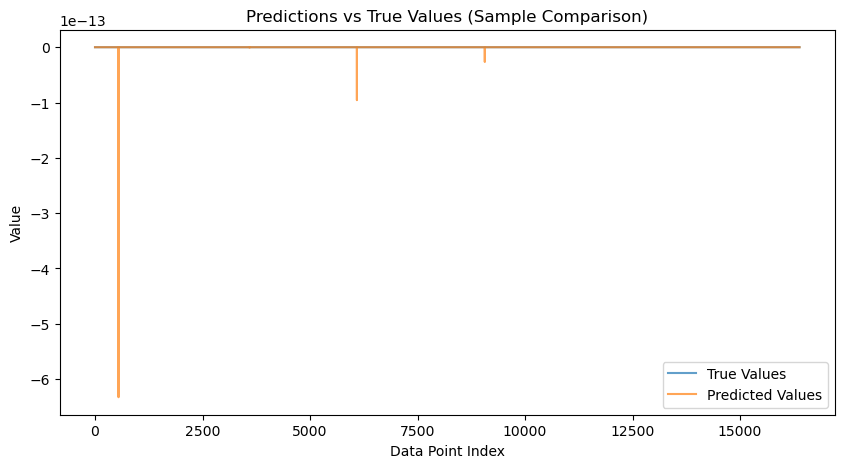

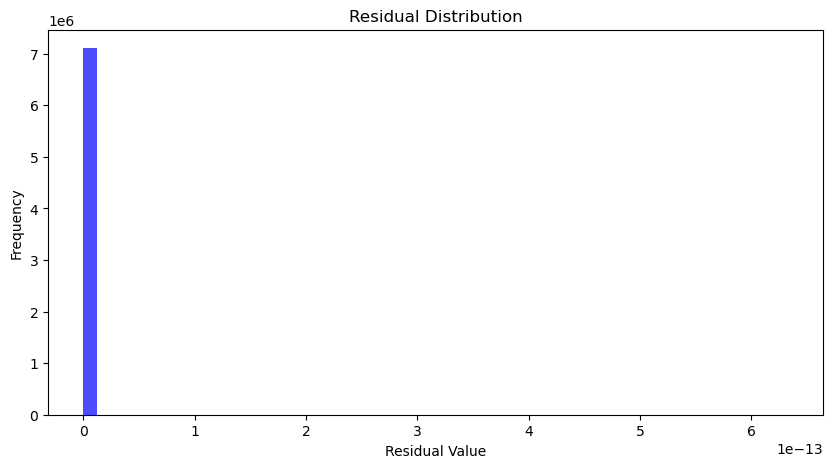

In [103]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Reshape original X_test to match the predicted output shape
y_true = X_test_true[..., :32]  # Extract the original unmasked energy channels (0-31)
y_pred = predicted_masked  # Predicted output from the model

# Flatten the arrays for metric calculations
y_true_flat = y_true.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# Calculate evaluation metrics
mse = mean_squared_error(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")

# Visualize the comparison for a random sample
sample_idx = 0  # Change this to visualize a different sample
y_true_sample = y_true[sample_idx].flatten()
y_pred_sample = y_pred[sample_idx].flatten()

plt.figure(figsize=(10, 5))
plt.plot(y_true_sample, label="True Values", alpha=0.7)
plt.plot(y_pred_sample, label="Predicted Values", alpha=0.7)
plt.title("Predictions vs True Values (Sample Comparison)")
plt.xlabel("Data Point Index")
plt.ylabel("Value")
plt.legend()
plt.show()

# Visualize residuals (optional)
residuals = y_true_flat - y_pred_flat
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, alpha=0.7, color="blue")
plt.title("Residual Distribution")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()
